<a href="https://colab.research.google.com/github/juandguerrero/megaline-revenue-analysis/blob/main/megaline2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Load all libraries

from scipy import stats as st
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np



## 1. Open the data files, study the general information, and prepare the data

In [ ]:
# Load the data files into different DataFrames
megaline_calls = pd.read_csv('megaline_calls.csv')
megaline_internet = pd.read_csv('megaline_internet.csv')
megaline_messages = pd.read_csv('megaline_messages.csv')
megaline_plans = pd.read_csv('megaline_plans.csv')
megaline_users = pd.read_csv('megaline_users.csv')

## Rates

In [ ]:
# Print the general/summary information about the Rates DataFrame

megaline_plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 260.0+ bytes


In [ ]:
# Print a sample of the data for the rates

megaline_plans.head()



,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


## Users

In [ ]:
# Print the general/summary information about the user DataFrame

megaline_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


In [ ]:
# Print a sample of user data

# Random sample of 5 rows from the original dataframe
print('Random sample of 5 rows from the original dataframe\n\n' )
print(megaline_users.sample(n=5))
print("\n\n\n")

# Random sample of 5 rows from the dataframe filtered by the rows with values ​​present in the 'churn_date' column
print("Random sample of 5 rows from the dataframe filtered by the rows with values ​​present in the 'churn_date' column\n\n" )
filtered_df = megaline_users[megaline_users['churn_date'].notnull()]
print(filtered_df.sample(n=5))
print("\n\n\n")

# Count the duplicate values ​​in the dataset
print('Duplicate values:',megaline_users.duplicated().sum())

Random sample of 5 rows from the original dataframe


     user_id first_name  last_name  age  \
275     1275      Elvie  Velazquez   33   
465     1465    Arianna   Morrison   73   
126     1126   Jermaine    Mcguire   68   
186     1186     Josiah    Douglas   55   
286     1286      Casie  Castaneda   52   

                                          city    reg_date      plan  \
275  New York-Newark-Jersey City, NY-NJ-PA MSA  2018-11-29  ultimate   
465                         Pittsburgh, PA MSA  2018-06-22  ultimate   
126     Chicago-Naperville-Elgin, IL-IN-WI MSA  2018-06-02  ultimate   
186       Las Vegas-Henderson-Paradise, NV MSA  2018-12-22  ultimate   
286                  New Haven-Milford, CT MSA  2018-12-07      surf   

     churn_date  
275         NaN  
465         NaN  
126         NaN  
186  2018-12-31  
286         NaN  




Random sample of 5 rows from the dataframe filtered by the rows with values ​​present in the 'churn_date' column


     user_id first_name  la

In [ ]:

# Change the data type of columns 'reg_date' and 'churn_date' to datetime

megaline_users['churn_date'] = pd.to_datetime(megaline_users['churn_date'])
megaline_users['reg_date'] = pd.to_datetime(megaline_users['reg_date'])


## Calls

In [ ]:
# Print general/summary information about the call data frame
megaline_calls.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB


In [ ]:
# Print a sample of data for the calls
print(megaline_calls.sample(n=5))


              id  user_id   call_date  duration
63193   1228_117     1228  2018-11-21      6.41
81148   1292_100     1292  2018-09-15      0.00
102091  1362_856     1362  2018-03-19     10.42
130137  1467_373     1467  2018-12-13      0.00
5271    1022_537     1022  2018-06-07      2.55


In [ ]:
# Change the data type of the 'call date' column to datetime

megaline_calls['call_date'] = pd.to_datetime(megaline_calls['call_date'])



## Messages

In [ ]:
# Prints general/summary information about the message DataFrame

megaline_messages.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [ ]:
# Print a sample of data for the messages

megaline_messages.sample(n=5)

,id,user_id,message_date
64363,1409_118,1409,2018-10-27
54617,1346_120,1346,2018-05-22
42398,1276_63,1276,2018-09-13
11018,1077_289,1077,2018-03-11
40520,1261_163,1261,2018-04-03


In [ ]:
# Change the data type of the 'message date' column to datetime

megaline_messages['message_date'] = pd.to_datetime(megaline_messages['message_date'])

## Internet

In [ ]:
# Print the general/summary information about the internet DataFrame

megaline_internet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB


In [ ]:
# Print a data sample of internet traffic

megaline_internet.sample(n=5)

,id,user_id,session_date,mb_used
41332,1185_369,1185,2018-01-24,260.30
93753,1437_678,1437,2018-12-02,325.33
24792,1114_67,1114,2018-09-05,702.36
33706,1153_221,1153,2018-11-29,256.23
60528,1276_12,1276,2018-12-30,246.81


In [ ]:
# Change the data type of the 'session date' column to datetime
megaline_internet['session_date'] = pd.to_datetime(megaline_internet['session_date'])

## 2. Group data by user



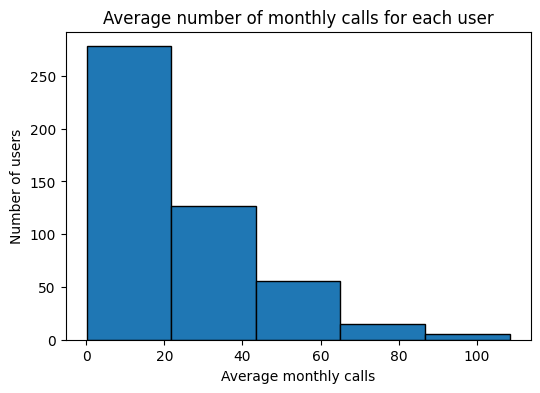

In [ ]:
# Calculate the average number of monthly calls for each user
average_user = megaline_calls.groupby('user_id')['id'].count()
average_user = average_user / 12.
plt.figure(figsize=(6, 4))
plt.hist(average_user, bins=5, edgecolor='black')


plt.title('Average number of monthly calls for each user')
plt.xlabel('Average monthly calls')
plt.ylabel('Number of users')


plt.show()

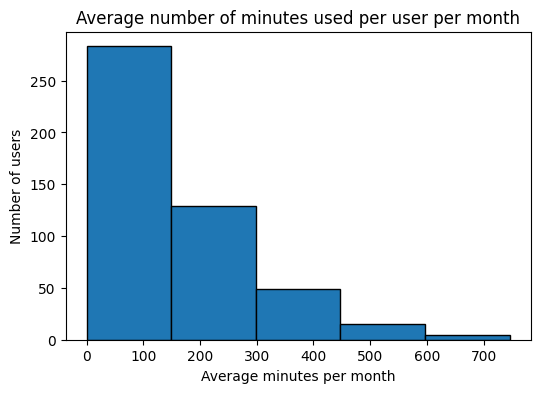

In [ ]:
# Calculate the number of minutes used by each user per month.

user_minutes_month = megaline_calls.groupby('user_id')['duration'].sum()
user_minutes_month = user_minutes_month / 12

# Create a histogram of user_minutes_month
plt.figure(figsize=(6, 4))
plt.hist(user_minutes_month, bins=5, edgecolor='black')

plt.title("Average number of minutes used per user per month")
plt.xlabel("Average minutes per month")
plt.ylabel("Number of users")

plt.show()


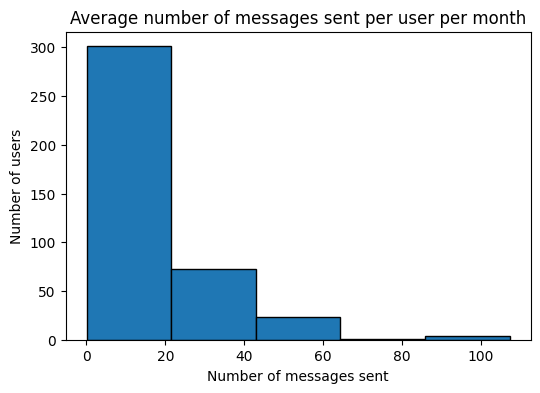

In [ ]:
# Calculate the number of messages sent by each user per month.

user_messages_month = megaline_messages.groupby('user_id')['id'].count()
user_messages_month = user_messages_month / 12

# Create a histogram of user_messages_month
plt.figure(figsize=(6, 4))
plt.hist(user_messages_month, bins=5, edgecolor='black')

plt.title("Average number of messages sent per user per month")
plt.xlabel("Number of messages sent")
plt.ylabel("Number of users")

plt.show()

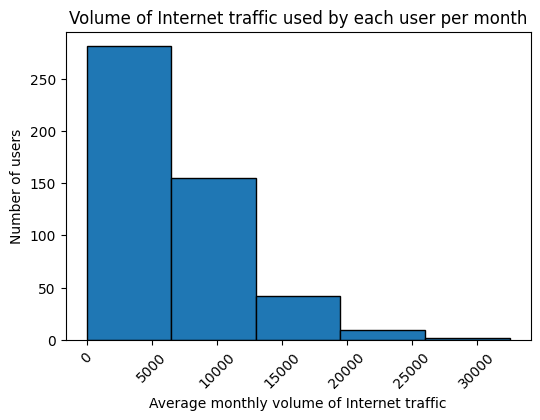

In [ ]:
# Calculate the volume of Internet traffic used by each user per month.

user_traffic_month = megaline_internet.groupby('user_id')['mb_used'].sum()
user_traffic_month = user_traffic_month/12

# Create a user traffic histogram for the month
plt.figure(figsize=(6, 4))
plt.hist(user_traffic_month, bins=5, edgecolor='black')

plt.title("Volume of Internet traffic used by each user per month")
plt.xlabel("Average monthly volume of Internet traffic")
plt.ylabel("Number of users")
plt.xticks(rotation=45)

plt.show()

In [ ]:
# Merge call, minute, message, and internet data based on user_id and month

# Create a 'month' column for each dataframe
megaline_calls['month'] = megaline_calls['call_date'].dt.to_period('M')
megaline_messages['month'] = megaline_messages['message_date'].dt.to_period('M')
megaline_internet['month'] = megaline_internet['session_date'].dt.to_period('M')

# Group each dataframe by user_id and month

# Total minutes and number of calls
megaline_calls['duration'] = np.ceil(megaline_calls['duration'])
calls_per_month = megaline_calls.groupby(['user_id', 'month']).agg(
    calls_count=('id', 'count'),
    total_minutes=('duration', 'sum')
).reset_index()


# Number of messages
messages_per_month = megaline_messages.groupby(['user_id', 'month']).agg(
    messages_count=('id', 'count')
).reset_index()

# Total data used
internet_per_month = megaline_internet.groupby(['user_id', 'month']).agg(
    mb_used=('mb_used', 'sum')
).reset_index()
internet_per_month['mb_used'] = np.ceil(internet_per_month['mb_used'] / 1024)

# Merge all datasets
merged_data = calls_per_month.merge(messages_per_month, on=['user_id', 'month'], how='outer')
merged_data = merged_data.merge(internet_per_month, on=['user_id', 'month'], how='outer')

# Replace NaN with 0
merged_data = merged_data.fillna(0)


print(merged_data.head())





   user_id    month  calls_count  total_minutes  messages_count  mb_used
0     1000  2018-12         16.0          124.0            11.0      2.0
1     1001  2018-08         27.0          182.0            30.0      7.0
2     1001  2018-09         49.0          315.0            44.0     14.0
3     1001  2018-10         65.0          393.0            53.0     22.0
4     1001  2018-11         64.0          426.0            36.0     19.0


      user_id    month  calls_count  total_minutes  messages_count  mb_used  \
0        1000  2018-12         16.0          124.0            11.0      2.0   
1        1001  2018-08         27.0          182.0            30.0      7.0   
2        1001  2018-09         49.0          315.0            44.0     14.0   
3        1001  2018-10         65.0          393.0            53.0     22.0   
4        1001  2018-11         64.0          426.0            36.0     19.0   
...       ...      ...          ...            ...             ...      ...   
2288     1498  2018-12         39.0          339.0             0.0     23.0   
2289     1499  2018-09         41.0          346.0             0.0     13.0   
2290     1499  2018-10         53.0          385.0             0.0     20.0   
2291     1499  2018-11         45.0          308.0             0.0     17.0   
2292     1499  2018-12         65.0          496.0             0.0     22.0   

          plan  monthly income  
0     ultimate    

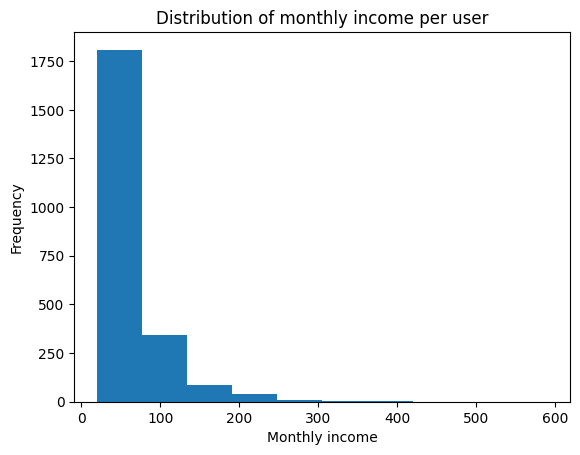

In [ ]:
# Calculate the monthly income for each user

# Add the plan column to the dataframe of calls, minutes,
# messages and Internet based on user_id and month

new_users = megaline_users[['user_id', 'plan']]
users_plan = merged_data.merge(new_users, on=['user_id'], how='left')

users_plan['monthly income'] = 0.0  # Create a column for monthly income

# base rate for 'surf' users
users_plan.loc[users_plan['plan'] == 'surf', 'monthly income'] = 20

# Extra charge for minutes over 500
users_plan.loc[
    (users_plan['total_minutes'] > 500) & (users_plan['plan'] == 'surf'),
    'monthly income'
] += (users_plan['total_minutes'] - 500) * 0.03

# Extra charge for messages over 50
users_plan.loc[
    (users_plan['messages_count'] > 50) & (users_plan['plan'] == 'surf'),
    'monthly income'
] += (users_plan['messages_count'] - 50) * 0.03

# Extra charge for data over 15 GB
users_plan.loc[
    (users_plan['mb_used'] > 15) & (users_plan['plan'] == 'surf'),
    'monthly income'
] += (users_plan['mb_used'] - 15) * 10

# base rate for 'ultimate' users
users_plan.loc[users_plan['plan'] == 'ultimate', 'monthly income'] = 70

# Extra charge for minutes over 3000
users_plan.loc[
    (users_plan['total_minutes'] > 3000) & (users_plan['plan'] == 'ultimate'),
    'monthly income'
] += (users_plan['total_minutes'] - 3000) * 0.01

# Extra charge for messages over 1000
users_plan.loc[
    (users_plan['messages_count'] > 1000) & (users_plan['plan'] == 'ultimate'),
    'monthly income'
] += (users_plan['messages_count'] - 1000) * 0.01

# Extra charge for data over 30 GB
users_plan.loc[
    (users_plan['mb_used'] > 30) & (users_plan['plan'] == 'ultimate'),
    'monthly income'
] += (users_plan['mb_used'] - 30) * 7

print(users_plan)


# Create a histogram of monthly income for each user

plt.hist(users_plan['monthly income'], bins=10)
plt.title('Distribution of monthly income per user')
plt.xlabel('Monthly income')
plt.ylabel('Frequency')
plt.show()



## 3. Analyze the data

### Calls

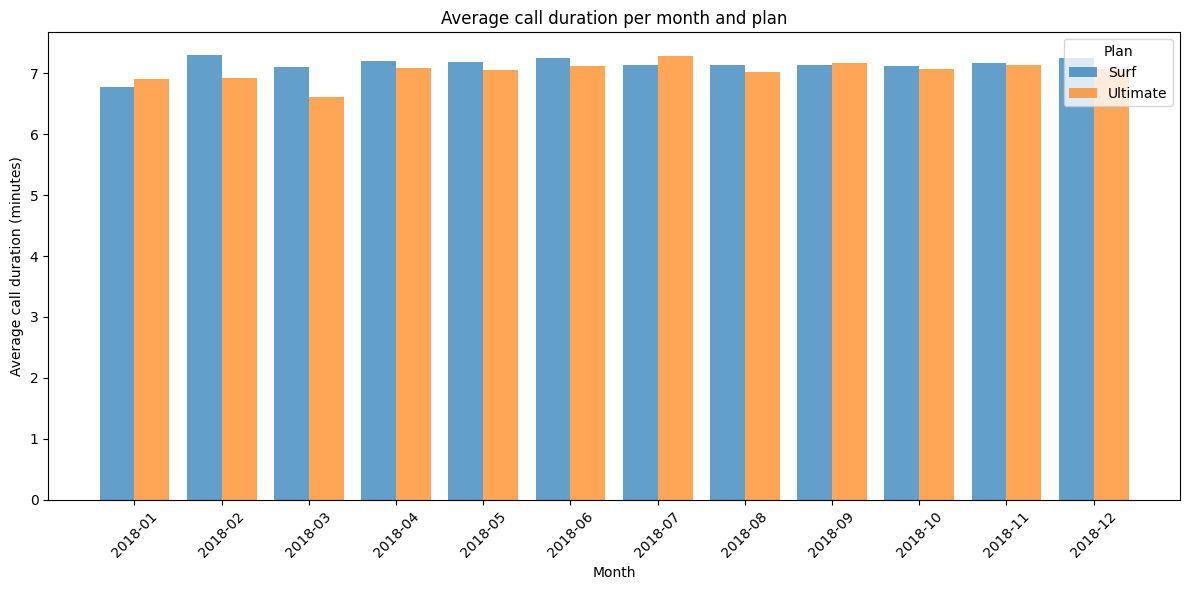

In [96]:
# Compare the average call duration for each plan and per month. Create a bar chart to visualize this.

# Group by plan and month and calculate the average duration of each call using .agg()
avg_duration = users_plan.groupby(['plan', 'month']).agg(
    avg_call_duration=('total_minutes', lambda x: x.sum() / users_plan.loc[x.index, 'calls_count'].sum())
).reset_index()

# Convert 'month' to a string so that matplotlib can plot it
avg_duration['month'] = avg_duration['month'].astype(str)

# Separate the data for each plan
surf = avg_duration[avg_duration['plan'] == 'surf'].sort_values('month').reset_index(drop=True)
ultimate = avg_duration[avg_duration['plan'] == 'ultimate'].sort_values('month').reset_index(drop=True)

# Draw both plans (side by side)
plt.figure(figsize=(12, 6))

x = range(len(surf))
bar_width = 0.4

plt.bar([i - bar_width/2 for i in x], surf['avg_call_duration'], width=bar_width, label='Surf', alpha=0.7)
plt.bar([i + bar_width/2 for i in x], ultimate['avg_call_duration'], width=bar_width, label='Ultimate', alpha=0.7)

plt.title('Average call duration per month and plan')
plt.xlabel('Month')
plt.ylabel('Average call duration (minutes)')
plt.xticks(x, surf['month'], rotation=45)
plt.legend(title='Plan')
plt.tight_layout()

plt.show()





In [ ]:
# Compare the number of monthly minutes needed by users of each plan. Draw a histogram.


# Create histogram
plt.figure(figsize=(10, 6))

# Represent both plans on the same graph
plt.hist(
    users_plan[users_plan['plan'] == 'surf']['total_minutes'],
    bins=30, alpha=0.6, label='Surf'
)

plt.hist(
    users_plan[users_plan['plan'] == 'ultimate']['total_minutes'],
    bins=30, alpha=0.6, label='Ultimate'
)


plt.title('Distribution of monthly minutes per plan')
plt.xlabel('Monthly minutes')
plt.ylabel('Frequency')
plt.legend(title='Plan')
plt.tight_layout()

plt.show()


In [ ]:
# Calculate the mean and variance of the monthly call duration.

mean_duration = users_plan['total_minutes'].mean()
variance_duration = users_plan['total_minutes'].var()

print(f"Average monthly call duration: {mean_duration:.2f} minutes")
print(f"Variance in monthly call duration: {variance_duration:.2f}")



In [ ]:
# Draw a box plot to visualize the distribution of monthly call duration

plt.figure(figsize=(8, 6))
sns.boxplot(x='plan', y='total_minutes', data=users_plan)

plt.title('Distribution of monthly call duration by plan')
plt.xlabel('Plan')
plt.ylabel('Monthly call duration (minutes)')
plt.tight_layout()
plt.show()

**Conclusions regarding user behavior with respect to calls. Does their behavior vary depending on the plan?**

The average call duration is very similar for both plans throughout the year.

There are significantly more users on the Surf plan.

Both plans show significant outliers to the right in monthly call duration.

No Ultimate plan user exceeded the minutes allowed in the Base plan. Many Surf plan users exceeded the minutes allowed in the Base plan.





### Messages

In [ ]:
# Compare the number of messages that users of each plan tend to send each month

# We group by plan and month, and calculate the average number of messages sent
messages_per_monthly_plan = (
    users_plan.groupby(['plan', 'month'])['messages_count']
      .mean()
      .reset_index()
      .sort_values(by=['plan', 'month'])
)

# Bar chart
plt.figure(figsize=(12, 6))
sns.barplot(
    data=messages_per_monthly_plan,
    x='month',
    y='messages_count',
    hue='plan'
)

plt.title('Average number of messages per month depending on the plan')
plt.xlabel('Month')
plt.ylabel('Average Messages Sent')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()





In [ ]:
# Compare the number of monthly messages needed by users of each plan. Draw a histogram.

# Create histogram
plt.figure(figsize=(10, 6))

# Represent both plans on the same graph
plt.hist(
    users_plan[users_plan['plan'] == 'surf']['messages_count'],
    bins=30, alpha=0.6, label='Surf'
)

plt.hist(
    users_plan[users_plan['plan'] == 'ultimate']['messages_count'],
    bins=30, alpha=0.6, label='Ultimate'
)


plt.title('Distribution of monthly messages per plan')
plt.xlabel('Monthly messages')
plt.ylabel('Frequency')
plt.legend(title='Plan')
plt.tight_layout()

plt.show()



In [ ]:
# Calculate the mean and variance of the number of monthly messages

mean_duration_messages = users_plan['messages_count'].mean()
variance_duration_messages = users_plan['messages_count'].var()

print(f"Average number of monthly messages: {mean_duration_messages} messages")
print(f"Variance in the number of monthly messages: {variance_duration_messages}")

# Draw a box plot to visualize the distribution of the number of monthly messages

plt.figure(figsize=(8, 6))
sns.boxplot(x='plan', y='messages_count', data=users_plan)

plt.title('Distribution of the number of monthly messages per plan')
plt.xlabel('Plan')
plt.ylabel('Number of monthly messages per plan')
plt.tight_layout()
plt.show()

**Conclusions Regarding User Behavior with Respect to Messaging**

The average number of monthly messages increased steadily for both plans throughout the year.

The average number of monthly messages was slightly higher for the Ultimate plan in all months.

No Ultimate plan user exceeded the 1,000 messages of the Base plan; all were well below that figure.

The highest number of messages sent for both plans was close to zero, indicating that a large number of users on both plans do not use messages at all.

In both plans, there are users who exceed the typical number of monthly messages consumed. The number of these users is higher and more dispersed on the Surf plan.





### Internet

In [ ]:
# Compare the amount of internet traffic consumed by users per plan

traffic_by_plan = (
    users_plan.groupby(['plan', 'month'])['mb_used']
      .mean()
      .reset_index()
      .sort_values(by=['plan', 'month'])
)

# Bar chart
plt.figure(figsize=(12, 6))
sns.barplot(
    data=traffic_by_plan,
    x='month',
    y='mb_used',
    hue='plan'
)

plt.title('Average monthly internet usage per plan')
plt.xlabel('month')
plt.ylabel('GB_used')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
# Compare the monthly data usage of users on each plan. Draw a histogram.

# Create histogram
plt.figure(figsize=(10, 6))

# Represent both plans on the same graph
plt.hist(
    users_plan[users_plan['plan'] == 'surf']['mb_used'],
    bins=30, alpha=0.6, label='Surf'
)

plt.hist(
    users_plan[users_plan['plan'] == 'ultimate']['mb_used'],
    bins=30, alpha=0.6, label='Ultimate'
)

plt.title('Distribution of data used monthly by plan')
plt.xlabel('monthly data usage')
plt.ylabel('Frequency')
plt.legend(title='Plan')
plt.tight_layout()

plt.show()


# Calculate the mean and variance of the monthly spending data

mean_duration_data = users_plan['mb_used'].mean()
variance_duration_data = users_plan['mb_used'].var()

print(f"Mean of the monthly data usage: {mean_duration_data}")
print(f"Variance of monthly spending data: {variance_duration_data}")

# Draw a box plot to visualize the distribution of data spent monthly

plt.figure(figsize=(8, 6))
sns.boxplot(x='plan', y='mb_used', data=users_plan)

plt.title('Distribution of data used monthly')
plt.xlabel('Plan')
plt.ylabel('Data used monthly')
plt.tight_layout()
plt.show()

**Conclusions on how users tend to consume internet traffic.**

The average monthly internet consumption was significantly lower for both plans in the first month of the year.

A large number of Surf plan users exceeded the data allowance of the Base plan.

Some Ultimate plan users exceeded the data allowance of the Base plan.

The distribution of monthly data usage for both plans is slightly skewed to the right.

There are rightward outliers in the distribution of monthly data usage for both plans. However, these outliers are more numerous and more dispersed in the Surf plan.


## Revenue

In [ ]:
# Compare the amount of monthly revenue consumed by users per plan

revenue_per_plan = (
    users_plan.groupby(['plan', 'month'])['monthly income']
      .mean()
      .reset_index()
      .rename(columns={'monthly income': 'average monthly income'})
      .sort_values(by=['plan', 'month'])
)

# Bar chart
plt.figure(figsize=(12, 6))
sns.barplot(
    data=revenue_per_plan ,
    x='month',
    y='average monthly income',
    hue='plan'
)

plt.title('Average monthly revenue by plan and month')
plt.xlabel('month')
plt.ylabel('average monthly revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



In [ ]:
# Compare the monthly revenue of users for each plan. Plot a histogram.

# Create histogram
plt.figure(figsize=(10, 6))

# Represent both plans on the same graph
plt.hist(
    users_plan[users_plan['plan'] == 'surf']['monthly income'],
    bins=30, alpha=0.6, label='Surf'
)

plt.hist(
    users_plan[users_plan['plan'] == 'ultimate']['monthly income'],
    bins=30, alpha=0.6, label='Ultimate'
)

plt.title('Distribution of users’ monthly revenue for each plan.')
plt.xlabel('Monthly revenue')
plt.ylabel('Frequency')
plt.legend(title='Plan')
plt.tight_layout()

plt.show()

# Calculate the mean and the variance of the monthly revenue

mean_revenue_duration = users_plan['monthly income'].mean()
revenue_duration_variance = users_plan['monthly income'].var()

print(f"Mean monthly revenue: {mean_revenue_duration}")
print(f"Variance of monthly revenue: {revenue_duration_variance}")

# Plot a box plot to visualize the distribution of monthly revenue by plan

plt.figure(figsize=(8, 6))
sns.boxplot(x='plan', y='monthly income', data=users_plan)

plt.title('Distribution of monthly revenue by plan')
plt.xlabel('Plan')
plt.ylabel('Monthly revenue')
plt.tight_layout()
plt.show()

**Conclusions on how revenue differs between the plans**

The average revenue of the Ultimate plan remained almost constant throughout the year.

The average revenue of the Surf plan showed an upward trend throughout the year.

For both plans, most of the revenue is concentrated near the base plan values.

There are significantly fewer users on the Ultimate plan.

In the Surf plan, revenue is highly variable: many users pay little, while some pay very large amounts.

In the Ultimate plan, revenue is stable and high. Almost all users pay similar amounts, and large outliers are not observed.

## 4. Test the statistical hypotheses

In [ ]:
# Separate the data by plan
surf_revenue = users_plan[users_plan['plan'] == 'surf']['monthly income']
ultimate_revenue = users_plan[users_plan['plan'] == 'ultimate']['monthly income']

# Levene's test (equality of variances)
levene_stat, levene_p = st.levene(surf_revenue, ultimate_revenue, center='mean')

print(f"Levene p-value (equality of variances): {levene_p:.5f}")

# Determine if the variances are equal
if levene_p < 0.05:
    equal_var_assumption = False
    print("Levene’s test conclusion: The variances are different → use Welch’s t-test")
else:
    equal_var_assumption = True
    print("Levene’s test conclusion: The variances are equal → use the standard t-test")


# t-test with automatic type selection
t_stat, p_value = st.ttest_ind(surf_revenue, ultimate_revenue, equal_var=equal_var_assumption)

print(f"\nT-test p-value: {p_value:.5f}")
print(f"T-statistic: {t_stat:.5f}")

# NaN Verification
if pd.isna(p_value):
    print("\n Warning: The p-value is NaN. Check the data: there may be missing values, constant values, or issues in the calculation")
else:
    if p_value < 0.05:
        print("\n Reject H₀ → The average revenues are significantly different between the plans.")
    else:
        print("\n Fail to reject H₀ → There is no evidence of a significant difference between the average revenues.")





In [ ]:
# Hypothesis test: comparison of revenues in NY vs the rest

# Add the city column to the compiled dataframe
users_city = megaline_users[['user_id', 'city']]
users_plan = users_plan.merge(users_city, on='user_id', how='left')

# Divide the data by city
ny_users = users_plan[
    users_plan['city'].str.contains('New York-Newark-Jersey City', case=False, na=False)
]
other_users = users_plan[
    ~users_plan['city'].str.contains('New York-Newark-Jersey City', case=False, na=False)
]

# Extract the revenues
ny_revenue = ny_users['monthly income']
other_revenue = other_users['monthly income']

# Levene’s test for equality of variances
levene_stat, levene_p = st.levene(ny_revenue, other_revenue, center='median')
print(f"Levene p-value: {levene_p}")

# Decide whether to use equal variances or not
equal_var_setting = True if levene_p > 0.05 else False

print(f"equal_var used in the t-test: {equal_var_setting}")

# t-test (depending on Levene)
t_stat, p_value = st.ttest_ind(ny_revenue, other_revenue, equal_var=equal_var_setting)

print(f"t-statistic: {t_stat}")
print(f"p-value t-test: {p_value}")

# Check for NaN
if pd.isna(p_value):
    print("The p-value is NaN → check for missing values, constant values, or problems in the data.")
elif p_value < 0.05:
    print("Reject H₀ → there is a significant difference in the average income between NY–NJ users and the others.")
else:
    print("Fail to reject H₀ → there is no significant difference in the average income.")





**5. General Conclusion**

Users of both plans use calls and messages in a similar way, although the Surf plan has many more users and shows more irregular consumption. In Surf, a large proportion of customers exceed the included minutes and data, which leads to very variable revenue: many users pay little, but some pay very high amounts, creating an upward trend in average revenue throughout the year.

In contrast, users of the Ultimate plan almost never exceed the limits and generate stable and high revenues, with little variation between months. This reflects a more predictable and homogeneous behavior, although with a much smaller user base.

Both plans show outliers in calls, messages, and data usage, but these are much more frequent and more dispersed in Surf. In addition, in both plans the revenues are concentrated near the base plan price, indicating that most users do not significantly exceed the included limits.

Overall, it can be concluded that Ultimate offers more consistent and higher revenues, while Surf generates more volatile revenues but with growth potential due to excess usage charges.